# 🖼️VLM视觉语言模型体验🎨
```
准备工作
1. 到硅基流动用手机号注册个账号，并绑定学校邮箱获得50元赠送余额
https://cloud.siliconflow.cn/
2. 新建API（应用程序接口，Application Programming Interface）密钥
https://cloud.siliconflow.cn/me/account/ak
3. 参考资料: 硅基流动的API手册
https://docs.siliconflow.cn/cn/api-reference/chat-completions/chat-completions#vlm
```
Vision Language Model，`input: text + image`，`output: text`

当前使用模型: `THUDM/GLM-4.1V-9B-Thinking`（支持图像理解和深度思考的视觉语言模型）


In [1]:
# 依赖安装
%pip install openai requests tiktoken ipywidgets rich gradio pillow -q

Note: you may need to restart the kernel to use updated packages.


# OpenAI格式的模型服务配置（全局设置）

In [2]:
# OpenAI格式的模型服务配置
from openai import OpenAI
import json

# 配置模型服务
client = OpenAI(
    base_url="https://api.siliconflow.cn/v1",
    # 模型推理服务地址 https://api.siliconflow.cn/v1 是*硅基流动*
    api_key="sk-dmayjpbwtbwhmabpywtvjinhfwxtyxkqijycrsvwanqhriin"    
    # 输入自己的连接密钥 https://cloud.siliconflow.cn/me/account/ak
)

# 多轮对话

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import base64
import json
from matplotlib import rcParams

# 配置中文字体（Windows 使用 SimHei，Mac 可改为 STHeiti，Linux 可改为 Noto Sans CJK）
# Configure Chinese font for Matplotlib
rcParams['font.sans-serif'] = ['SimHei']  
rcParams['axes.unicode_minus'] = False


def analyze_image_with_vlm(image_path, question="请描述这张图片"):
    """
    使用VLM分析图像
    
    Args:
        image_path: 图像文件路径
        question: 关于图像的问题
    """
    try:
        # 读取并编码图像
        with open(image_path, "rb") as image_file:
            base64_image = base64.b64encode(image_file.read()).decode('utf-8')
        
        # 构建消息
        messages = [
            {
                "role": "system",
                "content": "你是一个专业的图像分析助手，能够理解和分析图像内容，并回答相关问题。"
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": question},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    }
                ]
            }
        ]
        
        # 调用VLM模型
        response = client.chat.completions.create(
            model="THUDM/GLM-4.1V-9B-Thinking",
            messages=messages,
            max_tokens=500,
            temperature=0.7
        )
        
        return response.choices[0].message.content
        
    except Exception as e:
        return f"分析图像时出错: {str(e)}"


🔍 在当前目录找到 7 个图像文件:
  1. .\test_image (1).jpg
  2. .\test_image (2).jpg
  3. .\test_image (3).jpg
  4. .\test_image (4).jpg
  5. .\test_image (5).jpg
  6. .\test_image (6).jpg
  7. .\test_image (7).jpg


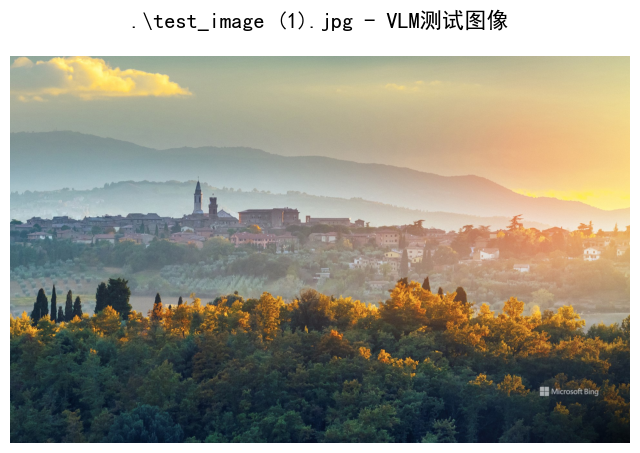

🎯 回答: 图中元素布局呈现由近及远的层次结构，具体如下：  
- **前景**：以茂密的树林为主，树木种类丰富，部分树木被阳光照射呈现出金黄色调，形成色彩明亮的“前景层”，植被分布较为密集，占据图像下半部分的大部分区域。  
- **中景**：是具有历史感的城镇建筑群，包含多种风格房屋（如带尖顶塔楼的建筑、低矮民居等），建筑群坐落在起伏的地形上，形成视觉中心，位于树林之后、山脉之前，色彩偏暖棕，与前景树林形成过渡。  
- **远景**：由连绵的山脉和天空构成，山脉呈现不同深浅的蓝灰色调，层次分明（近山稍深、远山渐浅），天空中有几朵被阳光染成金黄的云，整体天空色调由近到远从暖黄向浅灰过渡，为画面增添空间纵深感。  

此外，光线从画面右侧斜向洒入，给前景树林、中景建筑及远景山脉都赋予了暖色调光影，强化了各元素的层次与空间关系，整体布局自然和谐，兼具人文景观与自然景观的融合感。


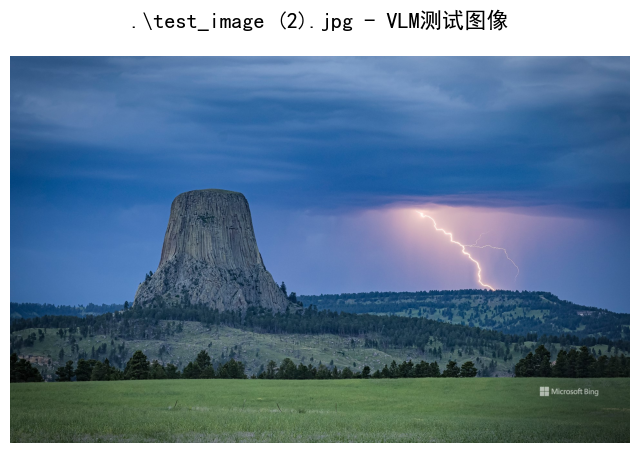

🎯 回答: 图中元素布局呈现出清晰的层次感与空间纵深感，具体可描述为：  
- **前景**：大片开阔的绿色草地，占据画面下方区域，平整且广袤，为画面提供开阔、舒展的基底感。  
- **中景**：分布着茂密树木的山丘，树木错落有致地覆盖在起伏山丘上，位于草地后方，与前景草地形成自然过渡层次。  
- **中心主体**：一处高耸的石柱形岩石（标志性地质景观），矗立在树木与山丘之间，是视觉焦点，占据画面中上部区域，以独特的形状和纹理成为画面核心。  
- **背景**：广阔的天空，占据画面上半部分，天空中布满厚重云层（色彩由深蓝色向浅蓝色渐变），右侧区域有闪电划过的明亮闪光，为画面增添动感和戏剧性氛围。  

整体布局上，元素从下到上、从近到远依次分布，草地、树木、岩石、天空形成自然空间层次，视觉焦点集中在中心岩石，背景的云层与闪电丰富了画面氛围感，各元素层次分明、相互呼应，构建出富有自然美感的景观场景。


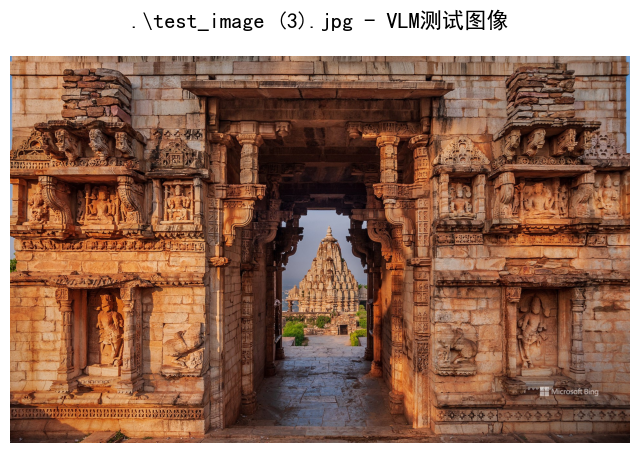

🎯 回答: 图中元素的布局呈现**纵深层次与对称结构**，具体如下：  

1. **近景（前景）**：以装饰繁复的石制门廊（ gateway ）为核心，占据画面中心与左侧大部分区域。门廊由石材建造，表面布满雕刻细节——两侧有对称的立柱，柱间及建筑表面分布多个雕刻壁龛，内含神像、浮雕等宗教或神话题材的艺术作品，雕刻风格细腻，造型各异，建筑整体呈现出历史遗迹的厚重感。  

2. **中景（通道）**：门廊后方的通道（石板铺就的步道）作为视觉的过渡空间，延伸向远方，引导观者视线。通道空间开阔但纵深，地面石板与建筑边缘形成对比，同时通道尽头有少量绿植点缀，增添自然气息。  

3. **远景**：通道尽头矗立着一座高耸的塔楼（圆锥形多层结构，类似古印度寺庙塔），成为画面的视觉焦点。塔楼在光线照射下显得庄严，与近景的门廊形成“前景—中景—远景”的纵深构图，强化了空间纵深感。  

4. **整体构图**：左右两侧的建筑结构（门廊及雕刻）基本对称，雕刻与建筑元素分布均匀，石材的暖色调（土黄、棕褐）在光线（推测为日出/日落时分）下更显古朴，营造出古老宗教遗址的历史氛围，同时通过空间层次（近—中—远）与对称结构，让画面既富有细节又整体协调。  


简言之，布局以“门廊—通道—塔楼”为空间主线，通过对称的建筑结构与纵深构图，展现古老遗址的庄严与历史质感。


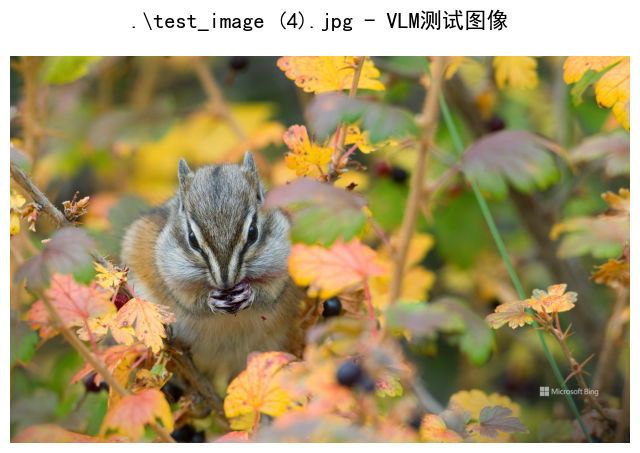

🎯 回答: 图中元素布局以中心的动物（花栗鼠）为核心，周围环绕着带有秋意色彩的植物（包含黄、橙、绿等多种色调的叶片以及浆果）。植物枝叶分布在中景和前景，从四周向中心方向形成环绕式布局，叶片与浆果错落排列，既围绕主体动物，又营造出自然、繁茂的生态环境氛围；背景为模糊的植物，通过景深效果突出中心动物，整体布局自然且层次分明，呈现出动物在自然植物环境中活动的场景，元素间通过色彩、位置关系形成和谐的画面构图。


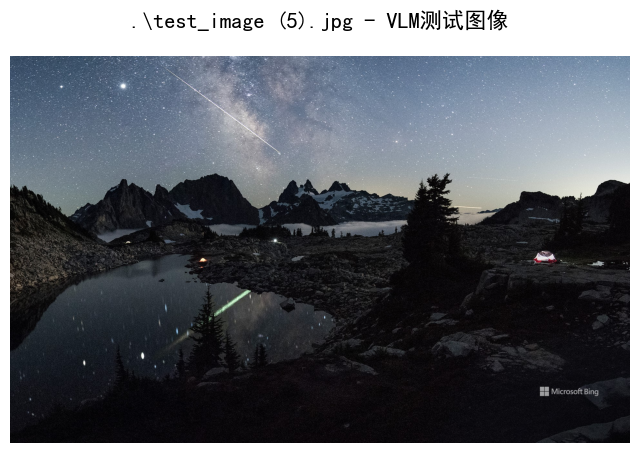

🎯 回答: 图中元素布局呈现自然景观的空间层次感，从上至下、从近及远可分为以下部分：  

1. **天空区域**：占据画面上半部分，呈现星空景象，有银河（带点状星光与带状光晕）、流星轨迹（或光带）点缀，天色从深灰渐变至浅蓝，接近黎明或黄昏的夜空，为画面提供开阔背景。  
2. **山体与地形**：位于画面中景和远景，多座陡峭山峰矗立，部分山峰有积雪覆盖，山体轮廓在星光下清晰可见。山体下方有云雾，增添朦胧感，山体从左至右分布，构成画面中部的垂直骨架。  
3. **水域（湖泊/池塘）**：处于画面中下部，是平静水面，反射星空、山体与环境，水面呈不规则形状，从画面左侧延伸至中间，以水平线条连接天空与地面，增强纵深感。  
4. **植被与岩石**：分布于水域周边和山体底部，有松树等深色轮廓的树木，以及散落的岩石。树木零星分布在山体边缘、湖边，岩石散落在湖岸与地面，增添自然粗犷质感。  
5. **人类设施（帐篷）**：在画面右侧中景的岩石上，有一顶亮灯的红色帐篷，作为人文元素点缀自然场景，位于山体与水域之间，与自然景观形成对比又和谐融合。  

整体布局通过“天空-山体-水域-地面”的空间分层，构建出纵深感，各元素色彩与明暗对比丰富，展现出夜晚高山自然景观与露营场景的融合，层次分明、相互呼应。


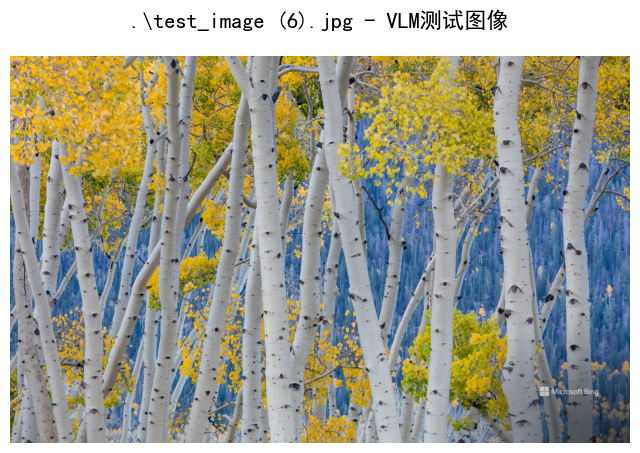

🎯 回答: 图中元素布局呈现自然且富有层次感的森林景象，具体如下：  

1. **主体元素（白桦树）**：画面中分布着多棵白桦树，树干密集且交错，占据画面的主要空间。树干为白色，带有黑色斑点，形成清晰的线条和纹理主导前景与中景区域。  

2. **树冠与树叶**：白桦树的树叶以明亮的黄色为主（可能为秋季色彩），分布在树干上方与间隙处，既填补了树干间的空隙，又通过色彩对比（黄与白的对比）形成视觉焦点，同时丰富了画面色彩层次。  

3. **背景层次**：远处有较暗色的树林，形成背景层次，与前景的白色树干、黄色树叶形成明暗、色彩上的对比，既衬托前景主体，又增强画面的空间纵深感，让整体布局更具立体感。  

4. **整体疏密与色彩分布**：元素分布上，树干与树叶既有密集感（形成自然的“森林感”），又有自然疏密变化（如部分树干空隙处可见背景，树叶分布也不完全均匀），色彩上以白色树干为底色，黄色树叶为亮点，深色背景为衬托，整体布局平衡且富有视觉节奏。  


简言之，图中以密集的白桦树干为基础，搭配色彩丰富的树冠与层次分明的背景，通过色彩、空间和元素的疏密变化，构建出自然、富有层次感的森林画面布局。


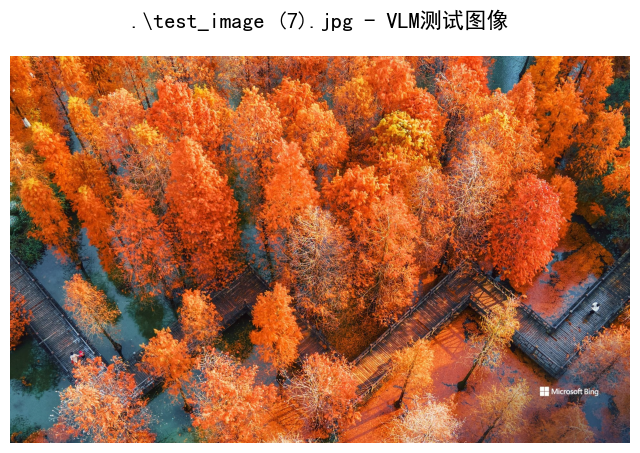

🎯 回答: 图中以空中俯瞰视角呈现自然与人文结合的景观，元素布局特点如下：  
画面主要由茂密树木、木质步道与水域构成。树木占据主要区域，以橙红色为主色调，呈密集且错落的分布，形成色彩丰富的森林景观；木质步道呈不规则网状穿插于树林与水域之间，部分步道上有行人，增添生活气息；水域分布在树木与步道之间，既作为自然分割元素，又通过反射树木色彩增强画面层次。  
整体布局中，树木作为主体形成视觉重心，木质步道与水域作为辅助元素相互交织，呈现自然景观与人文设施融合的错落有致、层次丰富的空间结构，色彩上暖色调树木与深色步道、水面形成鲜明对比，营造出秋季森林与休闲步道的和谐景观效果。


In [4]:
# 🎯 完整的VLM单轮对话测试 - 从目录自动获取图像文件

import os
import glob

# 从当前目录自动获取所有图像文件
def get_image_files(directory=".", extensions=None):
    """
    从指定目录获取所有图像文件
    
    Args:
        directory: 目录路径，默认为当前目录
        extensions: 图像文件扩展名列表，默认为常见格式
    """
    if extensions is None:
        extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.gif', '*.tiff', '*.webp']
    
    image_files = []
    for ext in extensions:
        pattern = os.path.join(directory, ext)
        image_files.extend(glob.glob(pattern))
        # 也搜索大写扩展名
        pattern = os.path.join(directory, ext.upper())
        image_files.extend(glob.glob(pattern))
    
    # 去重并排序
    image_files = sorted(list(set(image_files)))
    return image_files

# 获取图像文件列表
image_list = get_image_files()

print(f"🔍 在当前目录找到 {len(image_list)} 个图像文件:")
for i, img in enumerate(image_list, 1):
    print(f"  {i}. {img}")

if not image_list:
    print("❌ 当前目录中没有找到图像文件！")
    print("请确保目录中有以下格式的图像文件: jpg, jpeg, png, bmp, gif, tiff, webp")


#循环读图
for image_chosen in image_list:
    # 1. 显示图像
    img = Image.open(image_chosen)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{image_chosen} - VLM测试图像', fontsize=16, fontweight='bold', pad=20)
    plt.show()

    result = analyze_image_with_vlm(image_chosen, "请描述图中元素布局")
    print(f"🎯 回答: {result}")
    print("="*60)
